# BiomedParse Inference Demo Notebook

Welcome to the demo notebook for BiomedParse, a comprehensive tool for biomedical image analysis. BiomedParse is designed to simultaneously handle segmentation, detection, and recognition tasks across major biomedical image modalities, providing a unified solution for complex image analysis in biomedical research.

[[`Paper`](https://aka.ms/biomedparse-paper)] [[`Demo`](https://microsoft.github.io/BiomedParse/)] [[`Model`](https://huggingface.co/microsoft/BiomedParse)]  [[`Data`](https://huggingface.co/datasets/microsoft/BiomedParseData)]

## Model Checkpoint Access

The BiomedParse model checkpoint is hosted on [HuggingFace](https://huggingface.co/microsoft/BiomedParse). To access the model:

1. Visit the [model page](https://huggingface.co/microsoft/BiomedParse).
2. Make sure to review and accept the terms of use to gain access to the checkpoint.
3. Retrieve your HuggingFace access token from your user profile.

## Setting Up Access

To use the model, set your Hugging Face access token in the HF_TOKEN environment variable or as a Colab secret. This step ensures secure and authorized access to the model resources.

In [ ]:
# Set your Hugging Face access token in your environment
# import os
# os.environ['HF_TOKEN'] = 'your_huggingface_access_token_here'

# Or, if you are using Google Colab, set HF_TOKEN on Colab secrets.

In [4]:
from google.colab import output

# Prompt the user to input their Hugging Face token securely
token = input("Please enter your Hugging Face token: ")
output.clear()  # Clears the output for security

# Save the token as an environment variable
import os
os.environ["HF_TOKEN"] = token

In [6]:
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
from huggingface_hub import hf_hub_download

model_file = hf_hub_download(repo_id="microsoft/BiomedParse", filename="biomedparse_v1.pt", local_dir="pretrained")

print(f"Downloaded model file to: {model_file}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


biomedparse_v1.pt:   0%|          | 0.00/1.80G [00:00<?, ?B/s]

Downloaded model file to: pretrained/biomedparse_v1.pt


## Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!git clone https://github.com/microsoft/BiomedParse

Cloning into 'BiomedParse'...
remote: Enumerating objects: 1596, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 1596 (delta 66), reused 56 (delta 56), pack-reused 1517 (from 2)
Receiving objects: 100% (1596/1596), 652.52 MiB | 36.56 MiB/s, done.
Resolving deltas: 100% (475/475), done.
Updating files: 100% (583/583), done.
Filtering content: 100% (45/45), 69.68 MiB | 34.89 MiB/s, done.


In [9]:
!pip install -r BiomedParse/assets/requirements/requirements.txt

  Cloning https://github.com/MaureenZOU/detectron2-xyz.git to /tmp/pip-req-build-35p6xp0d
  Running command git clone --filter=blob:none --quiet https://github.com/MaureenZOU/detectron2-xyz.git /tmp/pip-req-build-35p6xp0d
  Resolved https://github.com/MaureenZOU/detectron2-xyz.git to commit 42121d75e10d9f858f3a91b6a39f5722c02868f0
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Prepari

# Restart Colab Runtime

In [ ]:
# Make sure to restart Colab runtime after installing dependencies
import os
try:
    import google.colab
    os._exit(0)
except ImportError:
    pass

In [1]:
import os
os.chdir('/content/BiomedParse')
print(os.getcwd())

/content/BiomedParse


## Load the model weights

In [2]:
from PIL import Image
import torch
import argparse
import numpy as np
from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed # changed from utils
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES
from inference_utils.inference import interactive_infer_image

conf_files = "configs/biomedparse_inference.yaml"
opt = load_opt_from_config_files([conf_files])
opt = init_distributed(opt)

model_file = "../pretrained/biomedparse_v1.pt"

model = BaseModel(opt, build_model(opt)).from_pretrained(model_file).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)

Deformable Transformer Encoder is not available.


/usr/local/lib/python3.11/dist-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/usr/local/lib/python3.11/dist-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


# Run Inference

In [3]:
# RGB image input of shape (H, W, 3). Currently only batch size 1 is supported.
image = Image.open('examples/Part_1_516_pathology_breast.png', formats=['png'])
image = image.convert('RGB')

# text prompts querying objects in the image. Multiple ones can be provided.
prompts = ['neoplastic cells', 'inflammatory cells']

pred_mask = interactive_infer_image(model, image, prompts)
pred_mask.shape

(2, 1024, 1024)

In [4]:
# load ground truth mask
gt_masks = []
for prompt in prompts:
    gt_mask = Image.open(f"examples/Part_1_516_pathology_breast_{prompt.replace(' ', '+')}.png", formats=['png'])
    gt_mask = 1*(np.array(gt_mask.convert('RGB'))[:,:,0] > 0)
    gt_masks.append(gt_mask)

# prediction with ground truth mask
for i, pred in enumerate(pred_mask):
    gt = gt_masks[i]
    dice = (1*(pred>0.5) & gt).sum() * 2.0 / (1*(pred>0.5).sum() + gt.sum())
    print(f'Dice score for {prompts[i]}: {dice:.4f}')

Dice score for neoplastic cells: 0.9022
Dice score for inflammatory cells: 0.9011


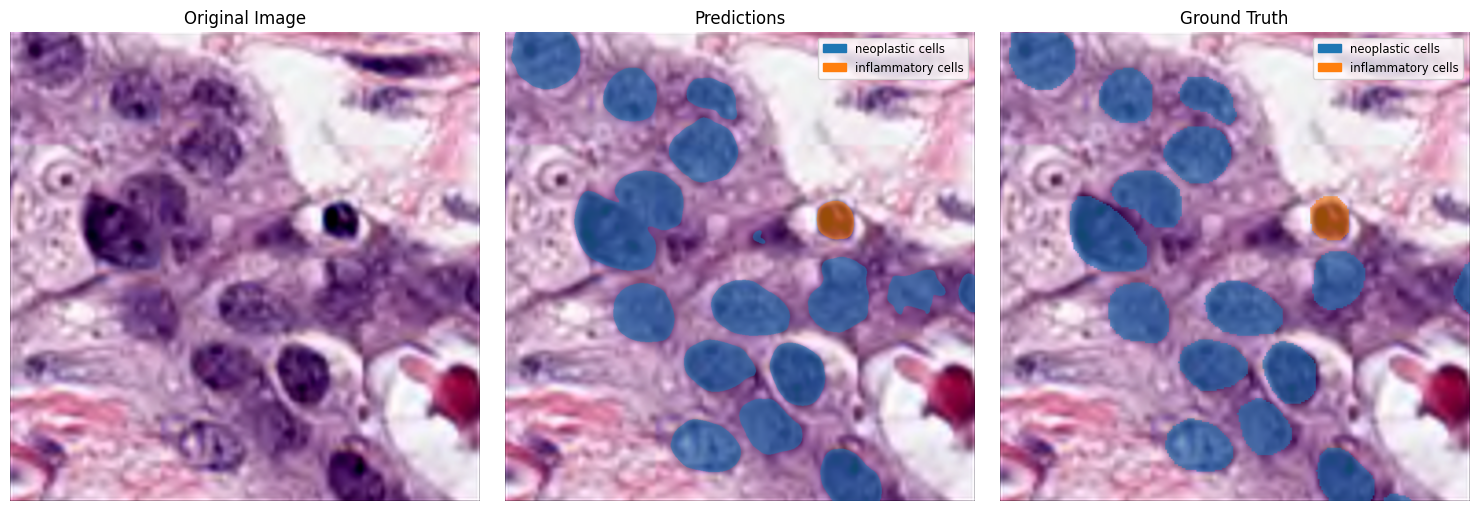

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as mpatches

def overlay_masks(image, masks, colors):
    overlay = image.copy()
    overlay = np.array(overlay, dtype=np.uint8)
    for mask, color in zip(masks, colors):
        overlay[mask > 0] = (overlay[mask > 0] * 0.4 + np.array(color) * 0.6).astype(np.uint8)
    return Image.fromarray(overlay)

def generate_colors(n):
    cmap = plt.get_cmap('tab10')
    colors = [tuple(int(255 * val) for val in cmap(i)[:3]) for i in range(n)]
    return colors

original_image = Image.open('examples/Part_1_516_pathology_breast.png').convert('RGB')

colors = generate_colors(len(prompts))

pred_overlay = overlay_masks(original_image, [1*(pred_mask[i] > 0.5) for i in range(len(prompts))], colors)

gt_overlay = overlay_masks(original_image, gt_masks, colors)

legend_patches = [mpatches.Patch(color=np.array(color) / 255, label=prompt) for color, prompt in zip(colors, prompts)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(pred_overlay)
axes[1].set_title("Predictions")
axes[1].axis('off')
axes[1].legend(handles=legend_patches, loc='upper right', fontsize='small')

axes[2].imshow(gt_overlay)
axes[2].set_title("Ground Truth")
axes[2].axis('off')
axes[2].legend(handles=legend_patches, loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# Test

## General Functions

In [6]:
def overlay_masks(image, masks, colors):
    overlay = image.copy()
    overlay = np.array(overlay, dtype=np.uint8)
    for mask, color in zip(masks, colors):
        overlay[mask > 0] = (overlay[mask > 0] * 0.4 + np.array(color) * 0.6).astype(np.uint8)
    return Image.fromarray(overlay)

# text prompts querying objects in the image. Multiple ones can be provided.
def generate_colors(n):
    cmap = plt.get_cmap('tab10')
    colors = [tuple(int(255 * val) for val in cmap(i)[:3]) for i in range(n)]
    return colors

def predict_and_show(prompts, image):
    colors = generate_colors(len(prompts))
    legend_patches = [mpatches.Patch(color=np.array(color) / 255, label=prompt) for color, prompt in zip(colors, prompts)]
    pred_mask = interactive_infer_image(model, image, prompts)
    pred_overlay = overlay_masks(image, [1*(pred_mask[i] > 0.5) for i in range(len(prompts))], colors)
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(pred_overlay)  # Replace with the overlay you want to display
    ax.set_title("Predictions")
    ax.axis('off')
    ax.legend(handles=legend_patches, loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

## Testing Wire Detection



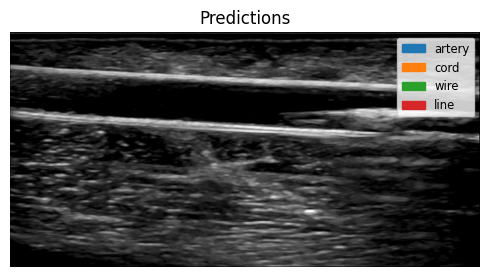

In [17]:
WIRE_IMG_PATH = '../drive/MyDrive/Img/exp13_30012025_7_0_1625/frame_000064.jpg'

wire_image = Image.open(WIRE_IMG_PATH).convert('RGB')
# cable, line, string, artery, cord, wire
prompts = ['artery', 'cord' , 'wire', 'line']

predict_and_show(prompts, wire_image)

## Testing Artery detection (ROI)

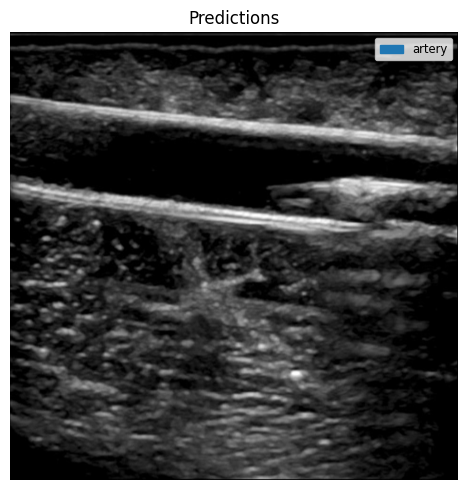

In [16]:
ARTERY_IMG_PATH = '../drive/MyDrive/Img/exp13_30012025_7_0_1625/frame_000064.jpg'
artery_image = Image.open(ARTERY_IMG_PATH).resize((1024,1024)).convert('RGB')
prompts = ['artery']

predict_and_show(prompts, artery_image)

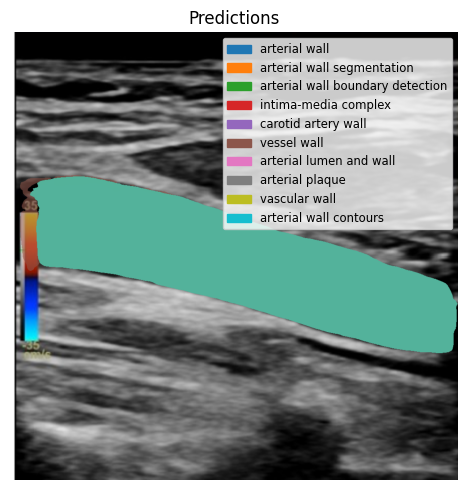

In [14]:
ARTERY_IMG_PATH = '../drive/MyDrive/Img/wire_images_video_1/artery_img.png'

artery_image = Image.open(ARTERY_IMG_PATH).resize((1024,1024)).convert('RGB')
prompts = [
    "arterial wall",
    "arterial wall segmentation",
    "arterial wall boundary detection",
    "intima-media complex",
    "carotid artery wall",
    "vessel wall",
    "arterial lumen and wall",
    "arterial plaque",
    "vascular wall",
    "arterial wall contours"
]

predict_and_show(prompts, artery_image)

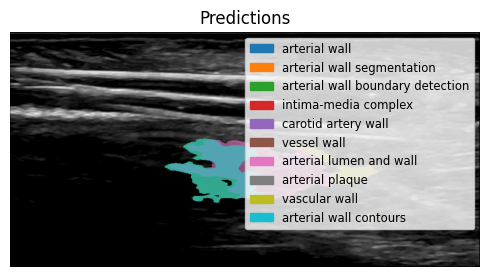

In [18]:
WIRE_IMG_PATH = '../drive/MyDrive/Img/exp13_30012025_7_0_1625/frame_000421.jpg'

wire_image = Image.open(WIRE_IMG_PATH).convert('RGB')
# cable, line, string, artery, cord, wire
prompts = [
    "arterial wall",
    "arterial wall segmentation",
    "arterial wall boundary detection",
    "intima-media complex",
    "carotid artery wall",
    "vessel wall",
    "arterial lumen and wall",
    "arterial plaque",
    "vascular wall",
    "arterial wall contours"
]

predict_and_show(prompts, wire_image)